# Setup

In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
import sys

sys.path.append("../utils")

import data_io

In [4]:
import colors
from embedding import plot_embedding, save_and_plot_feats
from mosaics import polygon_centroid, plot_multiple_mosaics
from dendrogram import ClusterDendrogram
from plot_cells import plot_cell_morphologies

# Data

In [5]:
config = data_io.get_data_config()
version = config.get("version", None)
skel_dir = config.get("skel_dir", None)
file_path = data_io.get_file_path(config)

assert os.path.isdir(skel_dir), skel_dir
assert os.path.isfile(file_path), file_path

In [6]:
df = pd.read_parquet(file_path)
df = df.drop(["polar_dens_1", "polar_dens_2"], axis=1)  # Not needed
df = data_io.restore_numpy_arrays(df)

print(df.shape)

Restoring numpy arrays in column: hull_points
(59003, 398)


## Labels

In [7]:
cellkinds = [
    'RGC',
    'AC',
    'dAC',
    'ON SAC',
    'OFF SAC',
    'BC',
]

In [8]:
def get_cellkind(row):
    cellclass = row['cellclass_final']
    celltype = row['celltype_final']
    soma_z = row['soma_z_um']

    if pd.isna(cellclass) or cellclass in ['BC', 'RGC']:
        return cellclass
    elif cellclass in ['AC']:
        if not pd.isna(celltype) and celltype in ['ON SAC', 'OFF SAC']:
            return celltype
        elif soma_z < 0:
            return 'dAC'
        else:
            return 'AC'

In [9]:
df['cellkind'] = df.apply(lambda x: get_cellkind(x), axis=1)

## TSNE

In [10]:
emb_cols_norm = [c for c in df.columns if c.startswith('ALLemb_norm')]
emb_cols_norm

['ALLemb_norm-r-PC0',
 'ALLemb_norm-r-PC1',
 'ALLemb_norm-r-PC2',
 'ALLemb_norm-r-PC3',
 'ALLemb_norm-t-PC0',
 'ALLemb_norm-t-PC1',
 'ALLemb_norm-z-PC0',
 'ALLemb_norm-z-PC1',
 'ALLemb_norm-z-PC2',
 'ALLemb_norm-z-PC3',
 'ALLemb_norm-z-PC4',
 'ALLemb_norm-z-PC5',
 'ALLemb_norm-z-PC6',
 'ALLemb_norm-z-PC7',
 'ALLemb_norm-z-PC8',
 'ALLemb_norm-z-PC9',
 'ALLemb_norm-res(rt)-PC0',
 'ALLemb_norm-res(rz)-PC0',
 'ALLemb_norm-res(tz)-PC0',
 'ALLemb_norm-soma_z_um',
 'ALLemb_norm-log_xys_dens_mean',
 'ALLemb_norm-log_hull_diameter',
 'ALLemb_norm-log_hull_perimeter',
 'ALLemb_norm-log_tips',
 'ALLemb_norm-log_branch_points',
 'ALLemb_norm-log_median_intermediate_segment_pl',
 'ALLemb_norm-log_median_terminal_segment_pl',
 'ALLemb_norm-log_tortuosity_median',
 'ALLemb_norm-branch_angle_median',
 'ALLemb_norm-branch_angle_mean',
 'ALLemb_norm-branch_angle_std',
 'ALLemb_norm-branch_angle_q5',
 'ALLemb_norm-branch_angle_q95',
 'ALLemb_norm-path_angle_median',
 'ALLemb_norm-path_angle_mean',
 'ALLe

In [11]:
len(emb_cols_norm)

43

In [12]:
df['include_in_embedding'] = (df["fda_weight"] > 0) & df["valid_cellclass_final"]

print(df['include_in_embedding'].sum())

21158


In [13]:
import scanpy as sc

adata = sc.AnnData(df.loc[df['include_in_embedding'], emb_cols_norm].values)
sc.tl.tsne(adata, perplexity=30, use_rep='X', random_state=0)  # 20?

In [14]:
df['tsne_d0'] = np.nan
df['tsne_d1'] = np.nan

df.loc[df["include_in_embedding"], 'tsne_d0'] = adata.obsm["X_tsne"][:, 0]
df.loc[df["include_in_embedding"], 'tsne_d1'] = adata.obsm["X_tsne"][:, 1]

# Figures

In [15]:
from style import set_rc_params

set_rc_params()

In [16]:
fig_dir = f'../figures/All/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## Z-Dens

In [17]:
df.rename({"perc_z_095_1": "perc_z_095", "perc_z_005_1": "perc_z_005"}, axis=1, inplace=True)

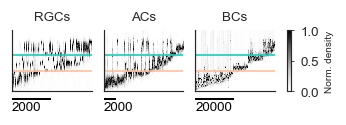

In [18]:
cellclasses = ['RGC', 'AC', 'BC']

fig, axs = plt.subplots(2, 4, figsize=(3, 0.8), sharex='col', height_ratios=(10, 1),
                        width_ratios=(1, 1, 1, 0.05))

for i, cellclass in enumerate(cellclasses):
    include = (df['cellclass_final'] == cellclass) & df['valid_cellclass_final']
    
    zi0 = 10
    zi1 = 100
    z0 = -20 + zi0*0.5
    z1 = -20 + zi1*0.5
    
    z_profiles_norm = np.vstack(df.loc[include, 'z_dens_1'])
    z_profiles_norm = z_profiles_norm[:, zi0:zi1]
    z_profiles_norm = (z_profiles_norm.T / (np.max(z_profiles_norm, axis=1) + 1e-20).T).T

    order = np.argsort(df.loc[include, "perc_z_005"])

    ax = axs[0, i]
    ax.set_title(cellclass + 's', fontsize=8)
    ax.set(xticks=[], yticks=[])
    im = ax.imshow(
        z_profiles_norm[order].T, aspect='auto', interpolation='none', origin='lower',
        extent=(0, z_profiles_norm.shape[0], z0, z1), rasterized=True, cmap='Grays')
    
    ax.axhline(0, ls='-', c=colors.cellclass2color['ON SAC'], lw=1)
    ax.axhline(12, ls='-', c=colors.cellclass2color['OFF SAC'], lw=1)

    ax = axs[1, i]
    ax.axis('off')

    if cellclass == 'BC':
        size = 20_000
    else:
        size = 2000
        
    ax.plot([0, size], [0.9, 0.9], c='k', solid_capstyle='butt')
    ax.text(0, 0.5, f'{size}', c='k', ha='left', va='top', fontsize=8)
    ax.set_ylim(0, 1)

cbar = plt.colorbar(im, ax=axs[0, -2], cax=axs[0, -1])
cbar.set_label('Norm. density', fontsize=6)
cbar.outline.set_visible(True)
axs[1, -1].axis('off')

fig.savefig(f'{fig_dir}/cellclass-z-profiles.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/cellclass-z-profiles.png', dpi=600, bbox_inches='tight')

## TSNE

/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/embedding.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


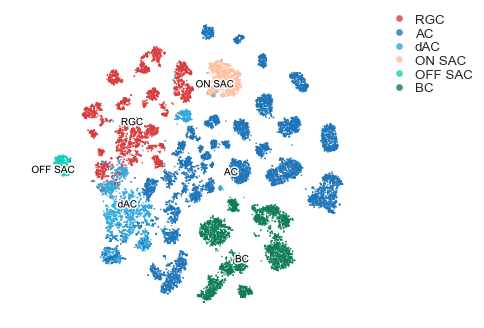

In [19]:
plot_embedding(
    df=df[df['include_in_embedding']],
    label2color=colors.cellclass2color,
    fig_path_prefix=f"{fig_dir}/class-tsne",
    celltype_col='cellkind',
    plot_order=cellkinds,
    is_labelled_col="valid_cellclass_final",
    dot_size=1,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=4,
    figsize=(4, 3.3)
)

/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/embedding.py:167: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


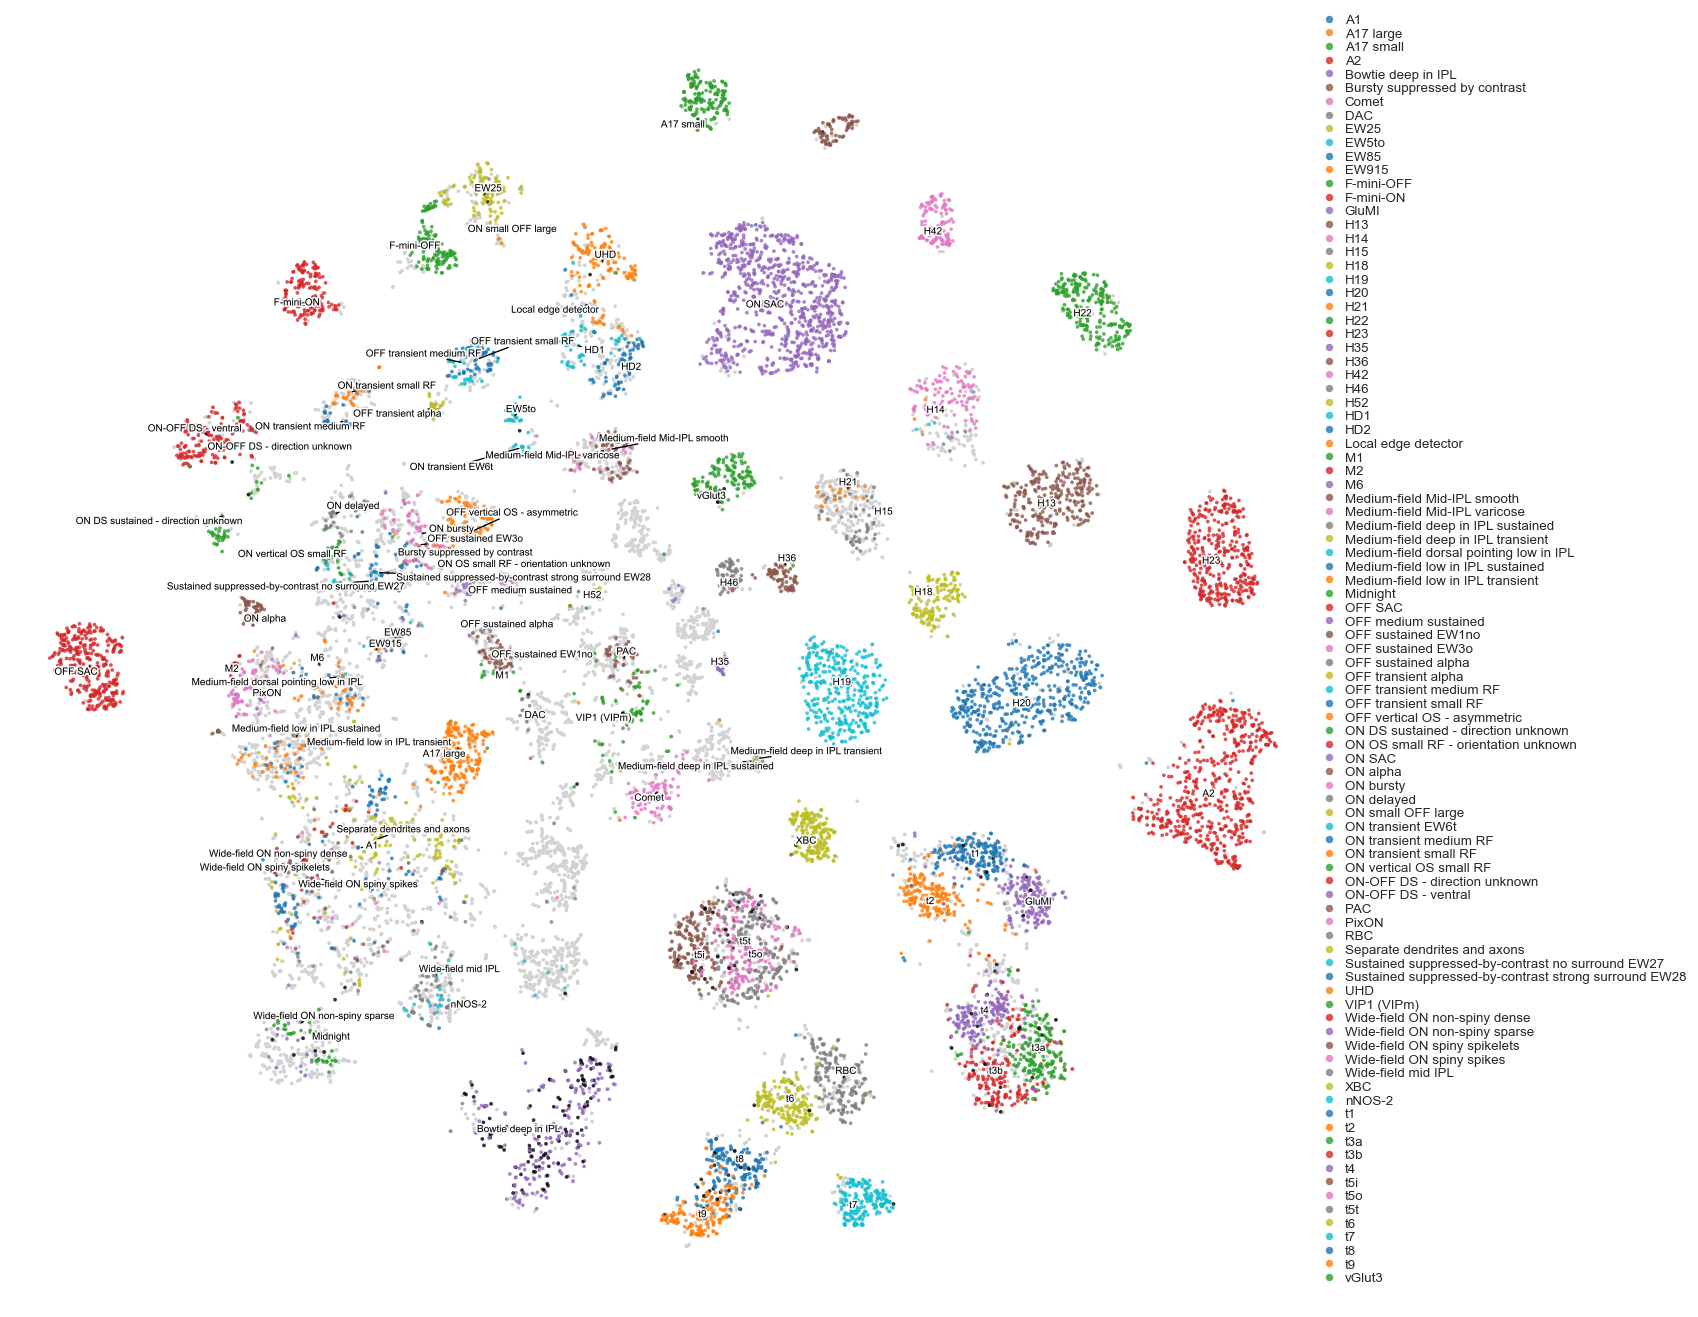

In [20]:
type_order = np.unique(df.loc[df['include_in_embedding'] & df['valid_celltype_final'], 'celltype_final'])

plot_embedding(
    df=df[df['include_in_embedding']],
    label2color={k: f'C{i}' for i, k in enumerate(type_order)},
    fig_path_prefix=f"{fig_dir}/class-tsne-celltype-for-ref",
    celltype_col='celltype',
    plot_order=type_order,
    is_labelled_col="valid_celltype_final",
    dot_size=5,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=2,
    figsize=(14, 14)
)

In [21]:
example_feature_names = [
    'perc_z_005',
    'perc_z_095',
    'log_radius_median',
    'log_tips',
    'log_hull_diameter',
]

example_features = df.loc[:, example_feature_names].values

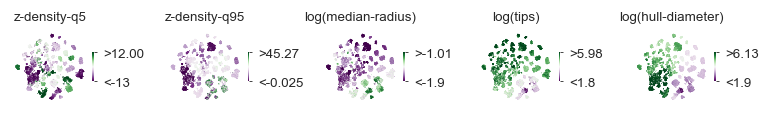

In [22]:
fig, axs = save_and_plot_feats(
    all_emb=df.loc[:, ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features,
    all_feat_names=example_feature_names, 
    ncols=5,
    clip=False,
    stride=1, 
    figsize_per_cell=(1.3, 1)
)

plt.tight_layout(h_pad=0.3)

fig.savefig(f'{fig_dir}/class-tnse-features.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/class-tnse-features.png', dpi=600, bbox_inches='tight')

## Examples

In [23]:
def plot_examples(name, rows, color, df, ):
    
    rad = np.maximum(20, (rows.hull_diameter.max() / 2) * 1.3)

    size = 1.8 * rad

    if size >= 1000:
        size = int(size // 1000) * 1000
    elif size >= 600:
        size = int(size // 200) * 200
    elif size >= 200:
        size = int(size // 100) * 100
    else:
        size = int(size // 50) * 50

    if size <= 20:
        size = 20
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(0.7*(len(rows)), 1.5), squeeze=False,
        height_ratios=(2.5, 3),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]))
    fig.subplots_adjust(wspace=0, hspace=0)
    
    for ax in axs.flat:
        ax.axis('off')
        
    print(rows.index.astype(int))

    fig, fig2 = plot_cell_morphologies(
        rows=rows,
        rad=rad,
        skel_dir=skel_dir,
        size=size,
        fig=fig,
        axs=axs,
        color=color,
        sb_fontsize=8,
        show_on_tsne=True,
        df=df,
        is_labelled=df['include_in_embedding'],
        labels=df['cellkind'],
        label_order=cellkinds,
        celltype2color=colors.cellclass2color,
        
    )

    axs[0, 1].set_title(celltype, fontsize=8)

    fig.savefig(f'{fig_dir}/celltype-example_{name}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype-example_{name}.png', dpi=600, bbox_inches='tight')
    
    fig2.savefig(f'{fig_dir}/celltype-example_{name}_on_tsne.png', dpi=200, bbox_inches='tight')
    
    plt.show()

In [24]:
prefer_label = df['include_in_embedding'] & df['valid_celltype_final'] & (df.celltype_final_decision == 'both_strong')

Index([720575940537038003, 720575940537340595, 720575940541316472], dtype='int64', name='cell')
[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.
[pywarper.surface] Optional dependency 'scikit-sparse' (CHOLMOD bindings) not found. Falling back to SciPy's sparse linear solver, which is ≈5–10× slower for large problems.

For platform-specific instructions see the project README:
	https://github.com/berenslab/pywarper#installation


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


15.6 69.0
12.6 68.6
24.9 66.8


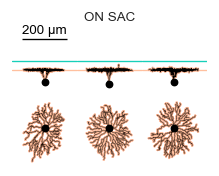

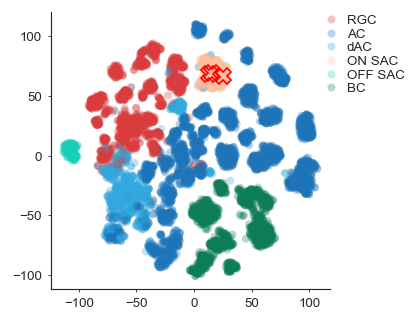

In [25]:
celltype = 'ON SAC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 8]]
plot_examples(celltype, rows, color=colors.cellclass2color[celltype], df=df)

Index([720575940547977603, 720575940545977605, 720575940546515205], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-104.9 -1.4
-102.5 0.4
-105.1 2.7


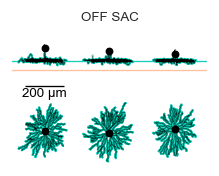

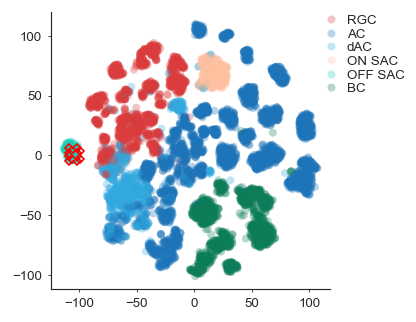

In [26]:
celltype = 'OFF SAC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[5, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color[celltype], df=df)

In [27]:
prefer_bcs = (df['status'] == 'ok') & (df['status_alt'] == 'yes') & (df['perc_z_098_1'] > 30)

Index([720575940545459029, 720575940545853013, 720575940550115936], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


20.0 -24.3
23.1 -24.6
21.7 -23.1


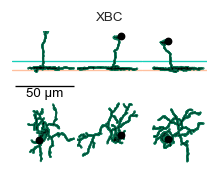

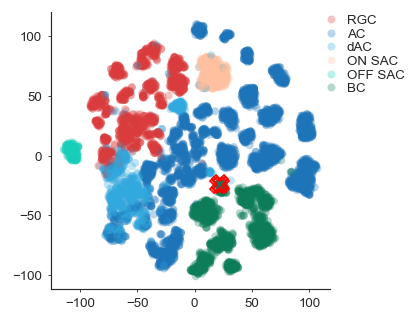

In [28]:
celltype = 'XBC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 4]]
plot_examples(celltype, rows, color=colors.cellclass2color['BC'], df=df)

Index([720575940545977659, 720575940547248354, 720575940548109187], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


36.6 -91.7
30.8 -95.1
32.1 -95.6


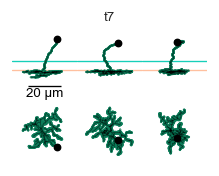

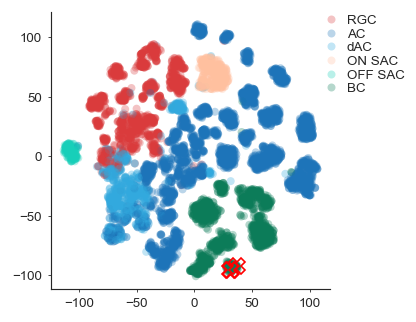

In [29]:
celltype = 't7'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['BC'], df=df)

Index([720575940545083106, 720575940546845113, 720575940547198528], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


28.5 -74.8
28.8 -76.5
28.2 -74.9


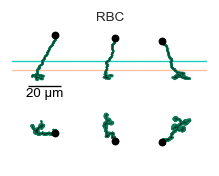

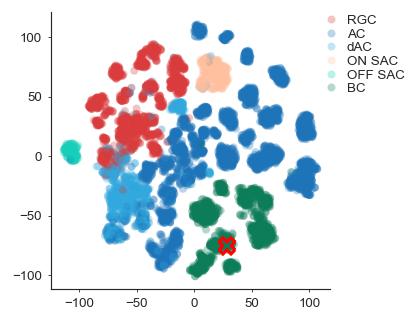

In [30]:
celltype = 'RBC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['BC'], df=df)

Index([720575940545021781, 720575940548829000, 720575940546771129], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


42.2 -35.5
46.3 -36.4
43.3 -37.8


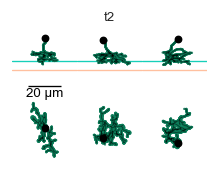

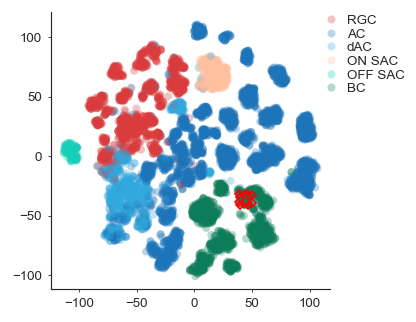

In [31]:
celltype = 't2'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 4, 3]]
plot_examples(celltype, rows, color=colors.cellclass2color['BC'], df=df)

Index([720575940537745467, 720575940545483763, 720575940540977784], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


102.6 -17.1
92.0 -5.8
101.1 -9.2


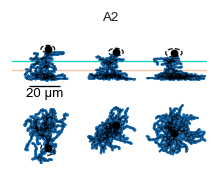

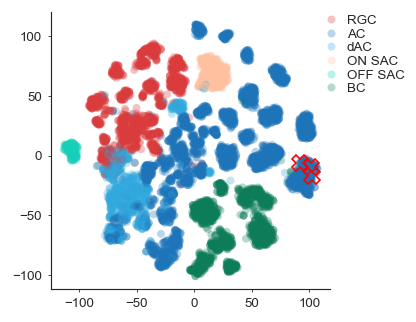

In [32]:
celltype = 'A2'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 3, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['AC'], df=df)

Index([720575940537111219, 720575940540887928, 720575940540929656], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


71.6 72.3
79.3 61.6
72.4 74.0


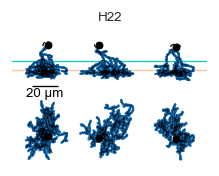

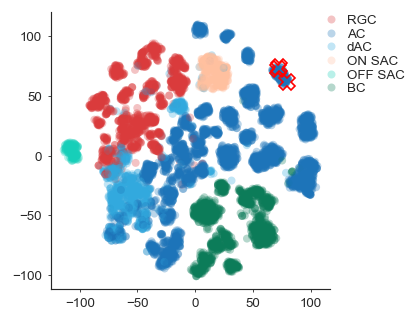

In [33]:
celltype = 'H22'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['AC'], df=df)

Index([720575940537001651, 720575940537190067, 720575940545518677], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


102.2 17.6
95.2 17.1
94.9 34.0


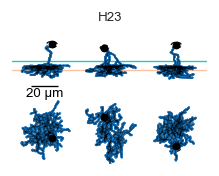

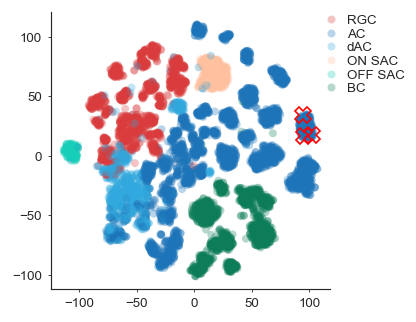

In [34]:
celltype = 'H23'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['AC'], df=df)

Index([720575940540958584, 720575940540987000, 720575940546011891], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-41.9 -7.8
-41.6 -18.2
-42.4 -16.6


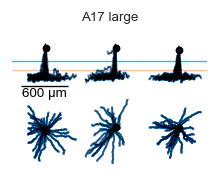

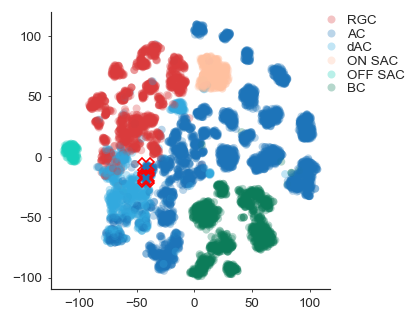

In [35]:
celltype = 'A17 large'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['AC'], df=df)

Index([720575940547396281, 720575940549376315, 720575940549861346], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-0.2 104.4
1.2 104.1
2.7 106.0


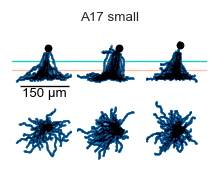

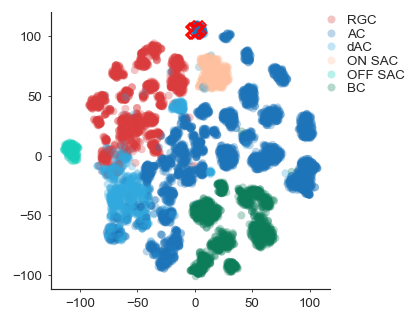

In [36]:
celltype = 'A17 small'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['AC'], df=df)

Index([720575940537569971, 720575940541163128, 720575940545348339], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-69.8 66.7
-68.2 72.1
-63.2 68.6


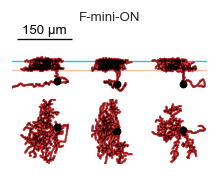

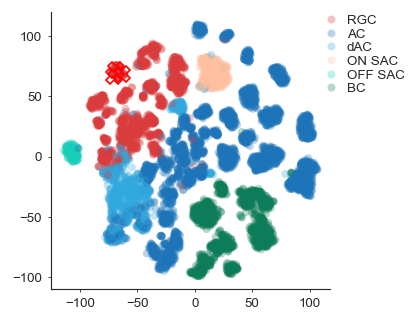

In [37]:
celltype = 'F-mini-ON'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['RGC'], df=df)

Index([720575940537434291, 720575940537466547, 720575940540777592], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-46.3 80.4
-47.0 75.0
-44.3 78.2


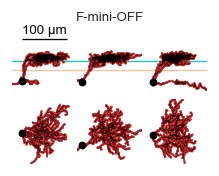

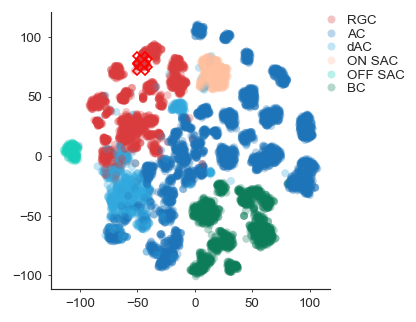

In [38]:
celltype = 'F-mini-OFF'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['RGC'], df=df)

Index([720575940550427362, 720575940553553059, 720575940553722711], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eyewire2/eyewire2-figures/notebooks/../utils/plot_cells.py:637: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-44.3 50.7
-44.9 50.5
-44.8 49.3


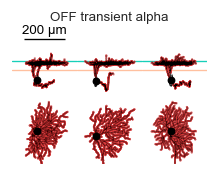

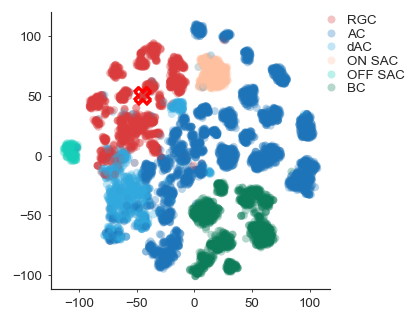

In [39]:
celltype = 'OFF transient alpha'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=colors.cellclass2color['RGC'], df=df)

## Mosaics

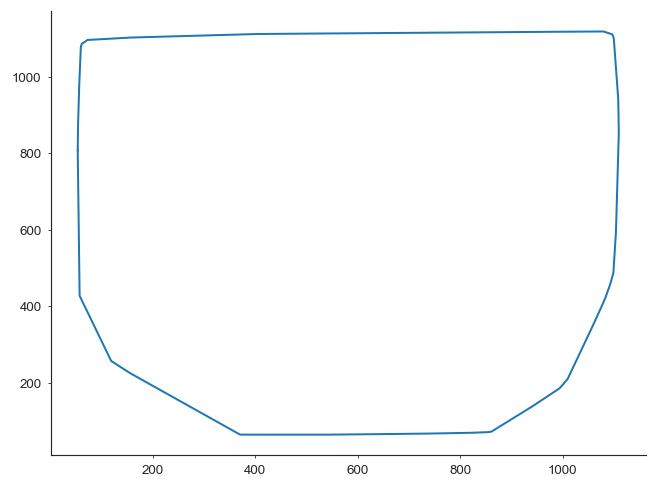

In [40]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

celltype='F-mini-ON': Found 160 cells and 72 candidates.
celltype='A2': Found 555 cells and 362 candidates.
celltype='H22': Found 233 cells and 120 candidates.
celltype='H23': Found 364 cells and 175 candidates.
celltype='ON SAC': Found 852 cells and 191 candidates.
celltype='OFF SAC': Found 337 cells and 53 candidates.
celltype='A17 large': Found 213 cells and 86 candidates.
celltype='A17 small': Found 167 cells and 52 candidates.
celltype='XBC': Found 671 cells and 10 candidates.
celltype='t7': Found 2218 cells and 40 candidates.


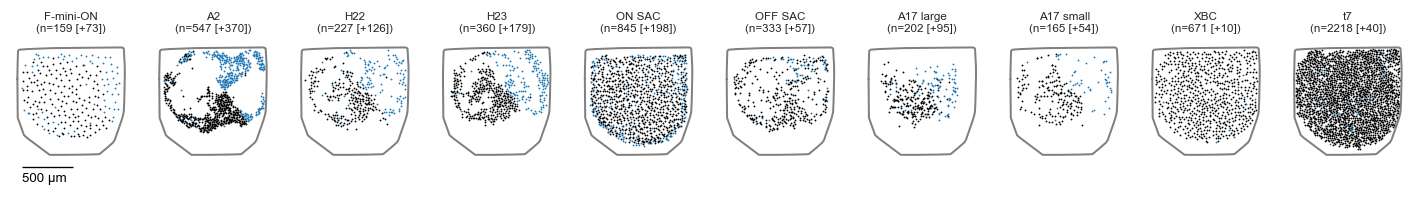

In [41]:
max_val = 7

celltypes = ['F-mini-ON', 'A2', 'H22', 'H23', 'ON SAC', 'OFF SAC', 'A17 large', 'A17 small', 'XBC', 't7']
marker_sizes = [1.2] * len(celltypes)
ncols = len(celltypes)

for name, extent in {'wide': [50, 1150, 50, 1150]}.items(): # 'zoom2': [200, 300, 600, 700], 'zoom': [200, 400, 600, 800]
    
    fig, axs = plt.subplots(ncols=len(celltypes), nrows=1, figsize=(len(celltypes)*1.5, 2),
                            sharex='row', sharey='row', squeeze=False)    
    if 'wide' in name.lower():
        sns.despine(top=True, right=True, left=True, bottom=True)
    else:
        sns.despine(top=False, right=False, left=False, bottom=False)
    
    ims, c_maxs = plot_multiple_mosaics(
        df=df[df.valid_celltype_final],
        celltype_col='celltype',
        candidate_col='celltype_final',
        candidate_color='C0',
        celltypes=celltypes,
        fig=fig,
        coverage_axs=None,
        resolutions=[1000] * ncols,
        center_axs=axs[0, :],            
        title_axs=axs[0, :],
        sb_axs=[axs[0, 0]],
        center_x_col="hull_center_x",
        center_y_col="hull_center_y",
        marker_sizes=marker_sizes,
        max_val=max_val,
        extent=extent,
        plot_outlines='zoom' in name.lower(),
        outline_hull=hull_pts if 'wide' in name.lower() else None,
        cb=False,
        sb_size=500 if 'wide' in name.lower() else 100,
        outline_kws = dict(c='gray', ls='-', clip_on=False),
    )

    for j, ax in enumerate(axs.flat):
        celltype = celltypes[j]
        df_ct = df[(df.celltype_final==celltype) & df.valid_celltype_final]
        n_cells = len(df_ct)
        n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
        n_cells_label = n_cells - n_cells_clf
        if n_cells_clf > 0:
            ax.set_title(f"{celltype}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
        else:
            ax.set_title(f"{celltype}\n(n={n_cells_label})", fontsize=7)
    
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.png', dpi=600, bbox_inches='tight')
    plt.show()

# Website

Only ACs here, rest is done in different notebooks

In [42]:
website_dir = f'../website/v{version}'
os.makedirs(website_dir, exist_ok=True)

In [43]:
website_cols = ['celltype_final', 'soma_x_um', 'soma_y_um', 'soma_z_um', 'soma_annot_x_um', 'soma_annot_y_um', 'soma_annot_z_um']

## Single examples

In [44]:
xy0 = np.array((48142, 36349)) * 16 / 1000
xy1 = np.array((42035, 31849)) * 16 / 1000
xy2 = np.array((37535, 37956)) * 16 / 1000
xy3 = np.array((43642, 42456)) * 16 / 1000

In [45]:
website_selection = ['A2', 'H22', 'H23', 'ON SAC', 'OFF SAC', 'A17 small', 'A17 large']

# Box center in um
box_center = (xy0 + xy1 + xy2 + xy3) / 4

website_rows = []
for celltype_final in website_selection:
    rows = df[
        (df.celltype_final == celltype_final)
        & df.valid_celltype_final
    ]
    
    if len(rows) == 0:
        website_rows.append(None)
        continue
    
    # Spatial distance to box center (medium priority)
    soma_xy = np.stack([rows.soma_annot_x_um, rows.soma_annot_y_um]).T
    spatial_dists = np.linalg.norm(soma_xy - box_center, axis=1)
    spatial_dists = np.clip(spatial_dists, 50, None)
    
    # tSNE distance to centroid (lowest priority, tiebreaker)
    emb_ct = np.stack([rows['tsne_d0'], rows['tsne_d1']]).T
    ct_mean = np.mean(emb_ct, axis=0)
    tsne_dists = np.linalg.norm(emb_ct - ct_mean, axis=1)
    
    # Strong flag (highest priority — invert so 0 = strong wins in argmin/lexsort)
    not_strong = (rows.celltype_final_decision != 'both_strong').values.astype(int)
    
    # lexsort sorts by LAST key as primary → put highest priority last
    order = np.lexsort((tsne_dists, spatial_dists, not_strong))
    row = rows.iloc[order[0]]
    
    website_rows.append(row)

df_website_single = pd.DataFrame(website_rows).loc[:, website_cols].copy()
df_website_single.sort_values('celltype_final', inplace=True)
df_website_single.head()

,celltype_final,soma_x_um,soma_y_um,soma_z_um,soma_annot_x_um,soma_annot_y_um,soma_annot_z_um
720575940555793382,A17 large,717.008,580.872,29.9358,716.128,578.992,82.56
720575940549861346,A17 small,677.928,571.752,31.4032,675.984,564.464,81.88
720575940551457701,A2,692.800,642.117,22.9376,695.456,640.896,70.36
720575940570288786,H22,676.412,614.956,30.4601,677.216,615.456,75.04
720575940557823832,H23,702.621,633.105,30.8992,699.920,629.136,78.04


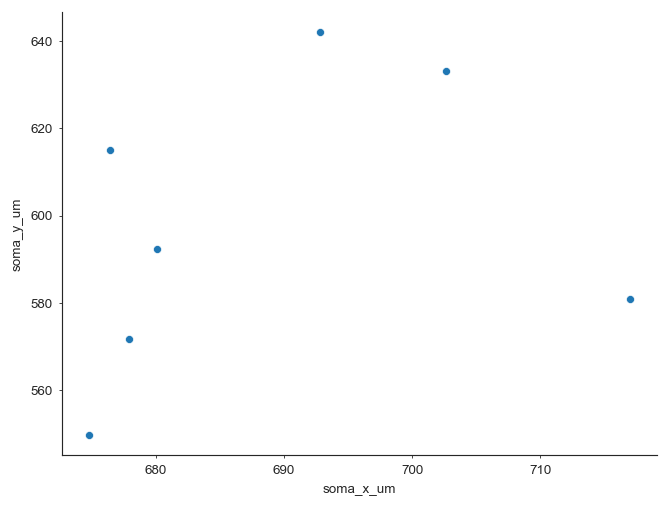

In [46]:
sns.scatterplot(df_website_single, x='soma_x_um', y='soma_y_um');

In [47]:
df_website_single.to_csv(os.path.join(website_dir, f"AC_website_single_examples.csv"))

In [48]:
df_website_single.index.astype(int)

Index([720575940555793382, 720575940549861346, 720575940551457701,
       720575940570288786, 720575940557823832, 720575940579980921,
       720575940554749466],
      dtype='int64')

## Mosaics

In [49]:
website_mosaics = ['ON SAC', 'OFF SAC']

df_website_mosaic = df.loc[df.valid_celltype_final & df.celltype_final.isin(website_mosaics), website_cols].copy()
df_website_mosaic.sort_values('celltype_final', inplace=True)
df_website_mosaic.head()

,celltype_final,soma_x_um,soma_y_um,soma_z_um,soma_annot_x_um,soma_annot_y_um,soma_annot_z_um
cell,,,,,,,
720575940563306959,OFF SAC,835.838,418.231,22.1912,838.768,415.072,82.12
720575940570124400,OFF SAC,719.783,785.847,30.0981,719.232,784.736,71.04
720575940570183275,OFF SAC,813.363,518.932,27.9985,812.112,514.880,81.64
720575940570243609,OFF SAC,1023.550,485.337,24.0443,1026.290,485.600,81.76
720575940558844452,OFF SAC,738.264,1005.310,27.6312,734.288,1000.660,68.04


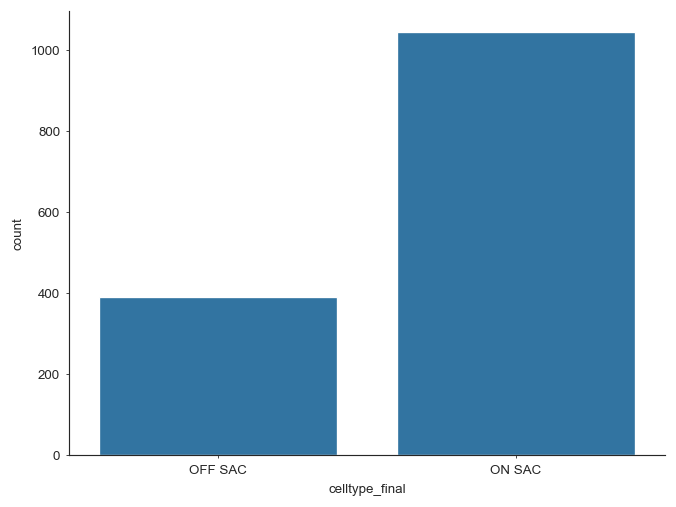

In [50]:
sns.countplot(data=df_website_mosaic, x='celltype_final');

In [51]:
df_website_mosaic.to_csv(os.path.join(website_dir, f"AC_website_mosaic_examples.csv"))